In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import bokeh.palettes
import numpy as np
import json

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [2]:
# open polybench.csv
with open("in/polybench.csv") as f:
    lines = f.readlines()
    lines = [line.strip() for line in lines]

data = []
for line in lines:
    suite, name, vm, time, memory = line.split(",")
    time = float(time)
    memory = int(memory)
    data.append((suite, name, vm, time, memory))

VMS = ['True-JIT', 'Wasmtime\n(Cranelift)', 'Wasmer\n(Singlepass)', 'Wasmer\n(Cranelift)', 'Wasmer\n(LLVM)', 'Wazero',
       'WAVM', 'GraalWasm']

NUM_OF_BENCHMARKS = 30
vms_times = [[] for _ in range(len(VMS))]
base_times = []
for b in range(NUM_OF_BENCHMARKS):
    for i, vm in enumerate(VMS):
        time = data[b * len(VMS) + i][3]
        if i == 0:
            base_time = time
            base_times.append(base_time)
        vms_times[i].append(time / base_time)

In [3]:
import scipy.stats.mstats as mstats

geometric_means = mstats.gmean(vms_times, axis=1, weights=base_times)
geometric_means

array([1.        , 0.98235385, 1.68774331, 1.01580531, 0.97962326,
       1.33307202, 0.97309562, 1.47390223])

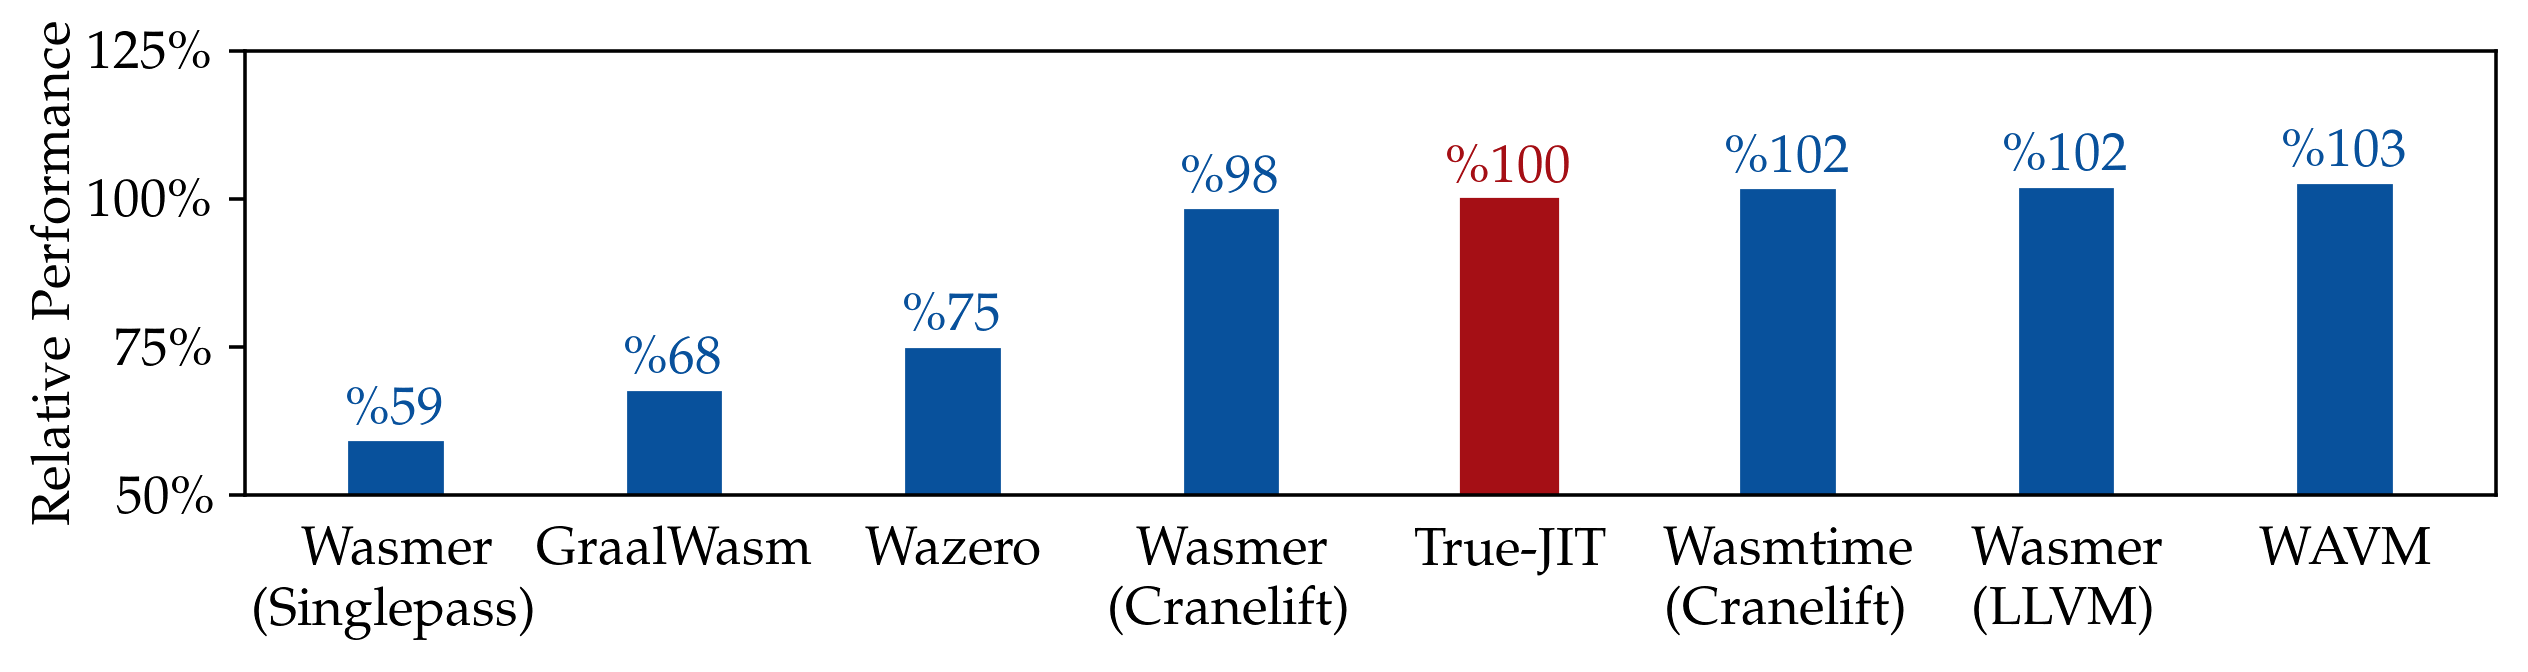

In [20]:
data = [(VMS[i], 1 / geometric_means[i]) for i in range(len(VMS))]

fig, ax = plt.subplots(figsize=(8, 2.2), dpi=320)

names = [x[0] for x in data]

times = [x[1] for x in data]
times = [x / times[0] for x in times]

# zip, sort, unzip
data = [(name, time) for name, time in zip(names, times)]
data = sorted(data, key=lambda x: x[1], reverse=False)
names, times = zip(*data)

# ax.bar(names, times, color="navy", width=0.25)
blue = bokeh.palettes.Blues5[0]
red = bokeh.palettes.Reds5[0]

ax.bar(names, times, color=blue, width=0.35, edgecolor='white', linewidth=0.5)

# x ticks size
ax.tick_params(axis='both', labelsize=12)

# y lim
ax.set_ylim(0.5, 1.25)

# y ticks every 0.25
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
# y label
ax.set_ylabel("Relative Performance", labelpad=1, fontsize=12)


# show the percentage on top of the markers
for i, v in enumerate(times):
    if i != 4:
        ax.text(i, v, f"\%{v * 100:.0f}", ha="center", va="bottom", color=blue, fontsize=12)
    else:
        ax.text(i, v, f"\%{v * 100:.0f}", ha="center", va="bottom", color=red, fontsize=12)

# truejit_label = ax.get_xticklabels()[4]
# truejit_label.set_color('crimson')
# truejit_label.set_fontweight('bold')

# get truejit bar and change its color
truejit_bar = ax.patches[4]
truejit_bar.set_color(red)

plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)

plt.tight_layout()

plt.savefig("out/speedup.pdf", bbox_inches="tight", pad_inches=0.05, dpi=320, transparent=True, format="pdf")

plt.show()